## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [1]:
# If you didn't download it yet, please get the relevant file now!
!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

--2025-01-29 12:55:59--  https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt
Risoluzione di www.dropbox.com (www.dropbox.com)... 162.125.69.18
Connessione a www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connesso.
Richiesta HTTP inviata, in attesa di risposta... 302 Found
Posizione: https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9 [segue]
--2025-01-29 12:55:59--  https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9
Riutilizzo della connessione esistente a www.dropbox.com:443.
Richiesta HTTP inviata, in attesa di risposta... 302 Found
Posizione: https://uc25df601817ec91afe57ec4c6ae.dl.dropboxusercontent.com/cd/0/inline/CjEN1ydK3XEBuguQb_m6YXpWbrHejDY8zSRm-mLR4oBewwaUstC_ZRJ3dwAjo2DBCrzU9dH3q7a273d7Vojfjp6o5DQ5Itv5c_0YRfI3HM4Kym9oILPcpgOAOAJ5_Eyl-1E/file# [segue]
--2025-01-29 12:56:00--  https://uc25df601817ec91afe57ec4c6ae.dl.dropboxusercontent.com/cd/0/inline/CjEN1ydK3XEBu

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the group-by method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

In [3]:
df = pd.read_csv(filepath_or_buffer='/Users/Filippo/data/data_000637.txt')
df.head()

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
0,1,0,123,3869200167,2374,26
1,1,0,124,3869200167,2374,27
2,1,0,63,3869200167,2553,28
3,1,0,64,3869200167,2558,19
4,1,0,64,3869200167,2760,25


2\. Find out the number of BX in a ORBIT (the value 'x').

In [4]:
max_orbit = float(df['ORBIT_CNT'].max())
min_orbit = float(df['ORBIT_CNT'].min())
orbit_increment = max_orbit - min_orbit
print(f"min:{min_orbit}, max:{max_orbit}, increment:{orbit_increment}")

min:3869200167.0, max:3869211171.0, increment:11004.0


In [5]:
max_bx = df['BX_COUNTER'].max()
min_bx = df['BX_COUNTER'].min()
x = max_bx - min_bx
print(f"min:{min_bx}, max:{max_bx}, increment:{x}")

#   we expect when bx passes the max value orbit_cnt increases by 1 count.

min:0, max:3563, increment:3563


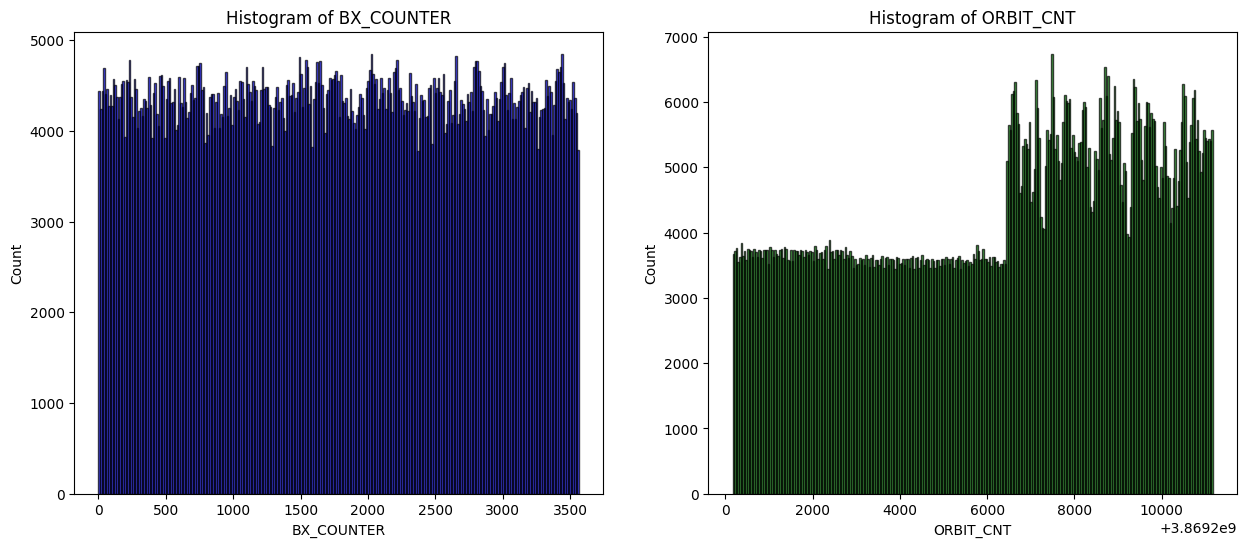

In [6]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.hist(df['BX_COUNTER'], bins=300, color='blue', alpha=0.7, edgecolor='black', range=(min_bx, max_bx+1))
plt.title('Histogram of BX_COUNTER')
plt.xlabel('BX_COUNTER')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(df['ORBIT_CNT'], bins=300, color='green', alpha=0.7, edgecolor='black', range=(min_orbit, max_orbit+1))
plt.title('Histogram of ORBIT_CNT')
plt.xlabel('ORBIT_CNT')
plt.ylabel('Count')

plt.show()

#   we that the bx_counter values are distributed evenly
#   over the measured period, which is expected assuming 
#   TDC continuously counting events with consistent time intervale
#   the spike in the "orbits count" might be due to the fact of
#   increased activity in certain periods???

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

In [7]:
#   BX = 25ns, TDC = 27.5 ns
BX_0 = df['BX_COUNTER'][0]
TDC_0 = df['TDC_MEAS'][0]
Data_time = ((df['ORBIT_CNT'].max()-df['ORBIT_CNT'].min())*x+BX_0+TDC_0/27.5)*25
Data_time

np.float64(980240673.6363636)

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

In [19]:
df['ABS_T_ns'] = (
    df['ORBIT_CNT']*x + df['BX_COUNTER']+df['TDC_MEAS']/27.5 
    )*25
df.head(10)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,ABS_T_ns
0,1,0,123,3869200167,2374,26,3.446490e+14
1,0,0,124,3869200167,2374,27,3.446490e+14
2,1,0,63,3869200167,2553,28,3.446490e+14
3,0,0,64,3869200167,2558,19,3.446490e+14
4,0,0,64,3869200167,2760,25,3.446490e+14
5,0,0,63,3869200167,2762,4,3.446490e+14
6,1,0,61,3869200167,2772,14,3.446490e+14
7,1,0,139,3869200167,2776,0,3.446490e+14
8,1,0,62,3869200167,2774,21,3.446490e+14
9,0,0,60,3869200167,2788,7,3.446490e+14


5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

In [20]:
df['HEAD'] = np.random.randint(0,2, size=len(df))
df['HEAD'].value_counts()

HEAD
1    656254
0    654466
Name: count, dtype: int64

In [21]:
#   6\. Create a new DataFrame that contains only the rows with HEAD=1.

df_one = df[df['HEAD']==1]
df_one.describe()

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,ABS_T_ns
count,656254.0,656254.000000,656254.000000,6.562540e+05,656254.000000,656254.000000,6.562540e+05
mean,1.0,0.294622,55.878055,3.869206e+09,1782.116921,13.326334,3.446495e+14
std,0.0,0.455873,39.020589,3.185474e+03,1027.544546,9.203291,2.837459e+08
min,1.0,0.000000,1.000000,3.869200e+09,0.000000,0.000000,3.446490e+14
25%,1.0,0.000000,26.000000,3.869203e+09,894.000000,5.000000,3.446493e+14
50%,1.0,0.000000,57.000000,3.869207e+09,1779.000000,13.000000,3.446496e+14
75%,1.0,1.000000,64.000000,3.869209e+09,2670.000000,21.000000,3.446498e+14
max,1.0,1.000000,139.000000,3.869211e+09,3563.000000,29.000000,3.446500e+14


6\. Create a new DataFrame that contains only the rows with HEAD=1.

In [49]:
FPGA_0 = df[df['FPGA']==0]
FPGA_1 = df[df['FPGA']==1]

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,ABS_T_ns


7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

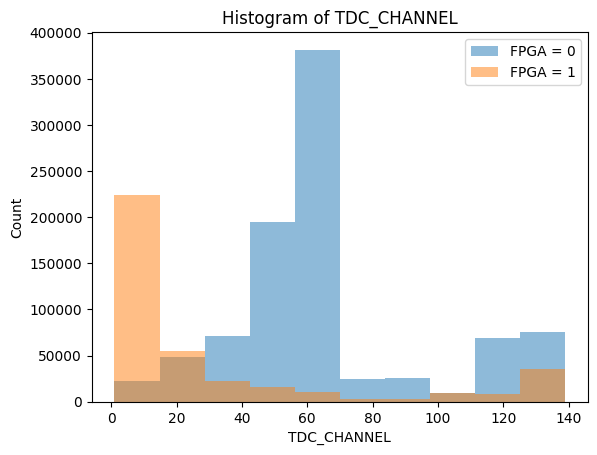

In [23]:
plt.hist(FPGA_0['TDC_CHANNEL'], alpha=0.5, label="FPGA = 0")
plt.hist(FPGA_1['TDC_CHANNEL'], alpha=0.5, label="FPGA = 1")
plt.title('Histogram of TDC_CHANNEL')
plt.xlabel('TDC_CHANNEL')
plt.ylabel('Count')
plt.legend()
plt.show()

8\. Use the group-by method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

In [42]:
df.groupby("TDC_CHANNEL").sum().sort_values(ascending=False, by="ORBIT_CNT").head(3)

,HEAD,FPGA,ORBIT_CNT,BX_COUNTER,TDC_MEAS,ABS_T_ns
TDC_CHANNEL,,,,,,
139,54271,32442,418102549486957,192477704,0,3.724248e+19
64,33002,1439,255444994368975,117767051,962195,2.275376e+19
63,32321,918,250113227630194,115482430,938192,2.227884e+19


9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [71]:
df["ORBIT_CNT"].nunique()

11001

In [70]:
df[df["TDC_CHANNEL"]==139]["ORBIT_CNT"].nunique()

10976

1. Channel Noise:
	+ If TDC_CHANNEL 139 is expected to record specific events or measurements but is active almost everywhere, it could be a noisy channel, generating excessive or unexpected measurements.
2.	Event Frequency:
	+	TDC_CHANNEL 139 might be linked to a specific type of event that occurs frequently across most orbits.
3.	Data Collection Focus:
	+	The dataset might be primarily focused on measurements from TDC_CHANNEL 139, with other channels contributing less.
4.	Systematic Issue:
	+	The high activity of TDC_CHANNEL 139 might indicate a systematic issue, such as misconfigured hardware or excessive logging from this channel.